In [33]:
!pip install qiskit
!pip install qiskit-aer


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [34]:
# Modern imports
import random
# import tensorflow as tf
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, Operator
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# from tensorflow.keras.optimizers import Adam
import numpy as np

# Fix random seed for reproducible examples (remove or change for real randomness)
random.seed(42)

# Backend simulator
backend = AerSimulator()

In [35]:
def random_bits(n: int) -> List[int]:
    return [random.randint(0, 1) for _ in range(n)]

def random_bases(n: int) -> List[int]:
    """Return 0 for Z-basis (|0>, |1>), 1 for X-basis (|+>, |->)"""
    return [random.randint(0, 1) for _ in range(n)]

def prepare_circuits_for_alice(bits: List[int], bases: List[int]) -> List[QuantumCircuit]:
    """Create one circuit per qubit encoding Alice's preparation."""
    circuits = []
    for b, basis in zip(bits, bases):
        qc = QuantumCircuit(1, 1)
        # encode bit in Z basis by applying X if bit==1
        if b == 1:
            qc.x(0)
        # if basis is X, apply H to prepare |+> / |->
        if basis == 1:
            qc.h(0)
        # leave a measurement placeholder for later (Bob or Eve will measure)
        circuits.append(qc)
    return circuits


def measure_in_basis_circuits(bases: List[int], incoming_circuits: List[QuantumCircuit]) -> List[QuantumCircuit]:
    """Given basis choices and existing single-qubit circuits (prepared qubit),
    append measurement operations for Bob (or Eve)."""
    circuits = []
    for basis, base_qc in zip(bases, incoming_circuits):
        qc = base_qc.copy()
        # if measuring in X basis, rotate with H before measuring
        if basis == 1:
            qc.h(0)
        qc.measure(0, 0)
        circuits.append(qc)
    return circuits


def run_circuits_get_bits(circuits: List[QuantumCircuit], shots: int = 1) -> List[int]:
    """Run circuits on AerSimulator in a batch and return list of measured bits (one shot per circuit).
    We assume one classical bit per circuit and shots=1 per circuit.)"""
    if not circuits:
        return []
    # transpile for backend
    t_circuits = transpile(circuits, backend=backend)
    job = backend.run(t_circuits, shots=shots)
    result = job.result()
    counts_list = [result.get_counts(i) for i in range(len(t_circuits))]
    measured = []
    for counts in counts_list:
        # counts is a dict like {'0': 1} or {'1': 1}
        # since shots=1, pick the single key
        bit = int(next(iter(counts)))
        measured.append(bit)
    return measured


def eve_intercept_resend(alice_circuits: List[QuantumCircuit], eve_bases: List[int]) -> List[QuantumCircuit]:
    """Eve measures each incoming qubit in her chosen basis, then re-prepares a fresh qubit in the result and basis she measured (intercept-resend).
    Returns new circuits prepared to be sent to Bob.
    """
    # First, measure Alice's circuits in Eve's bases
    measure_circuits = measure_in_basis_circuits(eve_bases, [qc.copy() for qc in alice_circuits])
    # run these to get measurement outcomes
    eve_measurements = run_circuits_get_bits(measure_circuits)

    # Now re-prepare qubits according to Eve's measurement results and send them onward
    forwarded = []
    for m, basis in zip(eve_measurements, eve_bases):
        qc = QuantumCircuit(1, 1)
        if m == 1:
            qc.x(0)
        if basis == 1:
            qc.h(0)
        # don't measure here (Bob will measure later)
        forwarded.append(qc)
    return forwarded


def sift_key(alice_bits: List[int], alice_bases: List[int], bob_bits: List[int], bob_bases: List[int]) -> Tuple[List[int], List[int], List[int]]:
    """Return (sifted_alice, sifted_bob, indices_kept) where we keep positions with matching bases."""
    sifted_a = []
    sifted_b = []
    indices = []
    for i, (ab, aa, bb) in enumerate(zip(alice_bases, alice_bits, bob_bits)):
        if ab == ab:  # no-op, kept for readability
            pass
        # keep if bases match
        if alice_bases[i] == bob_bases[i]:
            sifted_a.append(alice_bits[i])
            sifted_b.append(bob_bits[i])
            indices.append(i)
    return sifted_a, sifted_b, indices

def cascade(alice_key, bob_key, passes):

    corrected_bob = bob_key.copy()
    n = len(alice_key)

    for p in range(passes):
        block_size = max(1, n // (2 ** (p + 1)))

        for i in range(0, n, block_size):
            block_end = min(i + block_size, n)
            alice_parity = np.sum(alice_key[i:block_end]) % 2
            bob_parity = np.sum(corrected_bob[i:block_end]) % 2

            if alice_parity != bob_parity:
                low, high = i, block_end
                while high - low > 1:
                    mid = (low + high) // 2

                    temp_a = np.sum(alice_key[low:mid]) % 2
                    temp_b = np.sum(corrected_bob[low:mid]) % 2

                    if temp_a != temp_b:
                        high = mid
                    else:
                        low = mid

                corrected_bob[low] ^= 1

    return corrected_bob


    return corrected_bob

def error_rate(a_bits: List[int], b_bits: List[int]) -> float:
    if not a_bits:
        return 0.0
    mismatches = sum(x != y for x, y in zip(a_bits, b_bits))
    return mismatches / len(a_bits)

def add_noise(bits, noise_prob = 0.05):
    to_return = np.array(bits, dtype = int)
    flips = np.random.rand(len(bits)) < noise_prob
    to_return[flips] ^= 1

    return to_return.tolist()

In [7]:
class AdamOptimizer:
    """
    Adam optimizer implementation for quantum circuit learning.
    As mentioned in the paper (Section III), Adam is preferred over basic gradient descent.
    """
    def __init__(self, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # First moment estimate
        self.v = None  # Second moment estimate
        self.t = 0     # Time step

    def step(self, params, gradients):
        """Update parameters using Adam algorithm."""
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.t += 1

        # Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradients

        # Update biased second moment estimate
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradients ** 2)

        # Compute bias-corrected moment estimates
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        # Update parameters
        params_new = params - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

        return params_new

In [36]:
class ParameterTracker:
    """Simple tracker for successful parameter ranges."""

    def __init__(self, n_params):
        self.n_params = n_params
        self.successful_params = []

    def add_success(self, params):
        """Record a successful parameter set."""
        self.successful_params.append(params.copy())

    def get_smart_init(self):
        """
        Get initialization based on past successes.
        Returns either narrowed range or full range if not enough data.
        """
        if len(self.successful_params) < 3:
            # Not enough data yet, use full range
            return np.random.uniform(-np.pi, np.pi, self.n_params)

        # Compute statistics from successful runs
        params_array = np.array(self.successful_params)
        means = np.mean(params_array, axis=0)
        stds = np.std(params_array, axis=0)

        # Sample from learned distribution (with 2x std for exploration)
        new_params = means + 2.0 * stds * np.random.randn(self.n_params)

        # Clip to valid range
        new_params = np.clip(new_params, -np.pi, np.pi)

        return new_params

Quantum Circuit Learning Attack

In [ ]:
# ----------------------------------------- #
# Quantum Machine Learning Attack Functions #
# ----------------------------------------- #

def hardware_efficient_ansatz(n_qubits: int, n_layers: int, params: np.ndarray) -> QuantumCircuit:
  qc = QuantumCircuit(n_qubits)
  param_index = 0

  for layer in range(n_layers):
    for qubit in range(n_qubits):
      qc.rx(params[param_index], qubit)
      param_index += 1
      qc.ry(params[param_index], qubit)
      param_index += 1
      qc.rz(params[param_index], qubit)
      param_index += 1

    if n_qubits > 1:
      for qubit in range(n_qubits):
        qc.cx(qubit, (qubit + 1) % n_qubits)

  return qc

def pccm_circuit(theta: float) -> QuantumCircuit:
  qc = QuantumCircuit(2, 1)

  # PCCM gates on Eve's ancilla
  qc.rx(np.pi/2, 1)
  qc.ry(-np.pi, 1)
  qc.rz(-np.pi/2, 1)

  qc.cx(0, 1)

  qc.ry(theta, 1)
  qc.rx(-np.pi/2, 1)

  return qc

def compute_fidelity_density_matrix(rho_a: np.ndarray, rho_b: np.ndarray) -> float:
    """
    Compute quantum fidelity between two density matrices.
    F(ρ_a, ρ_b) = [Tr(√(√ρ_a ρ_b √ρ_a))]²

    Args:
        rho_a: First density matrix
        rho_b: Second density matrix

    Returns:
        Fidelity value between 0 and 1
    """
    # Ensure matrices are complex
    rho_a = np.array(rho_a, dtype=complex)
    rho_b = np.array(rho_b, dtype=complex)

    # Add small regularization for numerical stability
    eps = 1e-12
    rho_a = rho_a + eps * np.eye(len(rho_a))
    rho_b = rho_b + eps * np.eye(len(rho_b))

    # Compute sqrt of rho_a using eigendecomposition
    eigvals_a, eigvecs_a = np.linalg.eigh(rho_a)
    eigvals_a = np.maximum(eigvals_a, 0)  # Ensure non-negative
    sqrt_rho_a = eigvecs_a @ np.diag(np.sqrt(eigvals_a)) @ eigvecs_a.conj().T

    # Compute product sqrt(rho_a) @ rho_b @ sqrt(rho_a)
    product = sqrt_rho_a @ rho_b @ sqrt_rho_a

    # Get eigenvalues and compute trace of sqrt
    eigenvalues = np.linalg.eigvalsh(product)
    eigenvalues = np.maximum(eigenvalues, 0)  # Ensure non-negative

    # Fidelity is (sum of sqrt of eigenvalues)^2
    fidelity = np.sum(np.sqrt(eigenvalues))**2

    # Ensure result is in [0, 1]
    fidelity = np.clip(np.real(fidelity), 0, 1)

    return float(fidelity)

def get_density_matrix_from_circuit(qc: QuantumCircuit, num_qubits: int) -> np.ndarray:
    sv = Statevector.from_instruction(qc)
    dm = DensityMatrix(sv)
    return dm.data

def evaluate_attack_fidelities(u_params: np.ndarray, v_params: np.ndarray, n_qubits_u: int, n_layers_u, n_qubits_v: int, n_layers_v: int) -> Dict[str, float]:

  test_states = [(0, 0), (1, 0), (0, 1), (1, 1),]

  n_params_v_single = n_qubits_v * n_layers_v * 3
  v_params_z = v_params[:n_params_v_single]
  v_params_x = v_params[n_params_v_single:2*n_params_v_single]


  f_ab_list = []
  f_ae_list = []

  for bit, basis in test_states:

    qc_alice = QuantumCircuit(n_qubits_u)
    if bit == 1:
      qc_alice.x(0)
    if basis == 1:
      qc_alice.h(0)

    qc_u = hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params)
    qc_combined = qc_alice.compose(qc_u)

    statevec = Statevector.from_instruction(qc_combined)
    density_matrix_full = DensityMatrix(statevec)

    eve_qubits = list(range(1, n_qubits_u))
    dm_bob = partial_trace(density_matrix_full, eve_qubits)

    # Target state (same as before)
    if bit == 0 and basis == 0:
      target = np.array([[1, 0], [0, 0]], dtype=complex)
    elif bit == 1 and basis == 0:
      target = np.array([[0, 0], [0, 1]], dtype=complex)
    elif bit == 0 and basis == 1:
      target = np.array([[0.5, 0.5], [0.5, 0.5]], dtype=complex)
    else:
      target = np.array([[0.5, -0.5], [-0.5, 0.5]], dtype=complex)

    f_ab = compute_fidelity_density_matrix(target, dm_bob.data)
    f_ab_list.append(f_ab)

    dm_eve = partial_trace(density_matrix_full, [0])

    current_v_params = v_params_x if basis == 1 else v_params_z
    qc_v = hardware_efficient_ansatz(n_qubits_v, n_layers_v, current_v_params)
    U_v = Operator(qc_v)
    dm_eve_measured = U_v @ dm_eve.data @ U_v.adjoint()

    f_ae = compute_fidelity_density_matrix(target, dm_eve_measured)
    f_ae_list.append(f_ae)

  return {
      'F_AB': np.mean(f_ab_list),
      'F_AE': np.mean(f_ae_list)
  }

def qcl_loss_function(params: np.ndarray, target_f_ab: float, alpha: float, n_qubits_u: int, n_layers_u: int, n_qubits_v: int, n_layers_v: int) -> float:

  n_params_u = n_qubits_u * n_layers_u * 3
  n_params_v = n_qubits_v * n_layers_v * 3

  u_params = params[:n_params_u]
  v_params = params[n_params_u:n_params_u + 2*n_params_v]  # Both Z and X

  fidelities = evaluate_attack_fidelities(u_params, v_params, n_qubits_u,
                                          n_layers_u, n_qubits_v, n_layers_v)

  f_ab = fidelities['F_AB']
  f_ae = fidelities['F_AE']

  loss = alpha * (f_ab - target_f_ab) ** 2 - f_ae

  """
  f_ab_error = abs(f_ab - target_f_ab)
  if f_ab_error > 0.05:
    loss += 100.0 * (f_ab_error - 0.05) ** 3

  if f_ab > 0.5 and f_ab < 1.0:
    try:
      theta_from_fab = 2.0 * np.arccos(np.clip(2.0 * f_ab - 1.0, -1.0, 1.0))
      pccm_f_ae = (1.0 + np.sin(theta_from_fab / 2.0)) / 2.0

      if f_ae < pccm_f_ae - 0.01:
        # VERY STRONG penalty for being below curve
        below_curve_penalty = 200.0 * (pccm_f_ae - f_ae) ** 2
        loss += below_curve_penalty
    except:
      pass
  """
  return loss

def compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v, shift = np.pi/2):

  gradients = np.zeros_like(params)
  for i in range(len(params)):
    params_plus = params.copy()
    params_plus[i] += shift
    loss_plus = qcl_loss_function(params_plus, target_f_ab, alpha,
                                      n_qubits_u, n_layers_u,
                                      n_qubits_v, n_layers_v)

    params_minus = params.copy()
    params_minus[i] -= shift
    loss_minus = qcl_loss_function(params_minus, target_f_ab, alpha,
                                       n_qubits_u, n_layers_u,
                                       n_qubits_v, n_layers_v)

    # Compute gradient using parameter-shift rule
    gradients[i] = (loss_plus - loss_minus) / 2

  return gradients

def optimize_qcl_attack(target_f_ab: float = 0.85, alpha: float = 10.0, n_qubits_u: int = 2, n_layers_u: int = 2, n_qubits_v: int = 1, n_layers_v: int = 1, max_iter: int = 100, param_tracker = None, verbose: bool = True, tolerance: float = 1e-7) -> Dict:

  n_params_u = n_qubits_u * n_layers_u * 3
  n_params_v = n_qubits_v * n_layers_v * 3
  total_params = n_params_u + n_params_v * 2

  if verbose:
    print(f"  Optimizing {total_params} params, target F_AB={target_f_ab:.3f}")

  best_result = None
  best_distance = float('inf')
  n_attempts = 15
  lr_max = 0.40
  lr_min = 0.08
  max_patience = 30

  for attempt in range(n_attempts):

    # if param_tracker and attempt % 2 == 0:
      # params = param_tracker.get_smart_init()
    #else:
    params = np.random.uniform(-np.pi, np.pi, total_params)
    optimizer = AdamOptimizer(learning_rate=0.4)

    loss_history = []
    best_loss = float('inf')
    best_params = params.copy()
    patience = 0

    for iteration in range(max_iter):
      current_loss = qcl_loss_function(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)
      loss_history.append(current_loss)

      gradients = compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)

      grad_norm = np.linalg.norm(gradients)
      if grad_norm < 1e-8:
        break

      # Gradient Clipping
      max_grad_norm = 2.0
      if grad_norm > max_grad_norm:
        gradients = gradients * (max_grad_norm / grad_norm)

      # Smooth Cosine Annealing
      progress = iteration / max_iter
      current = lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))
      optimizer.lr = current
      params = optimizer.step(params, gradients)

      # Momentum Warmup
      if iteration < 30:
        optimizer.beta1 = 0.80
        optimizer.beta2 = 0.95
      else:
        optimizer.beta1 = 0.90
        optimizer.beta2 = 0.999

      if current_loss < best_loss - tolerance:
        best_loss = current_loss
        best_params = params.copy()
        patience = 0
      else:
        patience += 1

      if patience >= 75:
        print(f"Early stopping at iteration: {iteration + 1}")
        break

    u_params = best_params[:n_params_u]
    v_params = best_params[n_params_u:]
    final_fidelities = evaluate_attack_fidelities(u_params, v_params,
                                                  n_qubits_u, n_layers_u,
                                                  n_qubits_v, n_layers_v)

    f_ab = final_fidelities['F_AB']
    f_ae = final_fidelities['F_AE']

    f_ab_error = abs(f_ab - target_f_ab)

    theta = 2.0 * np.arccos(np.clip(2.0 * f_ab - 1.0, -1.0, 1.0))
    pccm_f_ae = (1.0 + np.sin(theta / 2.0)) / 2.0
    f_ae_gap = pccm_f_ae - f_ae

    distance = np.sqrt((f_ab_error * 2.0) ** 2 + f_ae_gap ** 2)

    if verbose:
       print(f"    Attempt {attempt+1}/{n_attempts}: "
            f"F_AB={f_ab:.4f} (err={f_ab_error:.4f}), "
            f"F_AE={f_ae:.4f} (gap={f_ae_gap:.4f}), "
            f"dist={distance:.4f}")

    if distance < best_distance:
      best_distance = distance
      best_result = {
        'u_params': u_params,
        'v_params': v_params,
        'F_AB': final_fidelities['F_AB'],
        'F_AE': final_fidelities['F_AE'],
        'loss': best_loss,
        'success': True,
        'loss_history': loss_history,
        'iterations': len(loss_history)
      }

      if param_tracker and f_ab_error < 0.05:
        param_tracker.add_success(best_params)

  return best_result if best_result else {
    'u_params': np.zeros(n_params_u),
    'v_params': np.zeros(2*n_params_v),
    'F_AB': 0.0, 'F_AE': 0.0, 'loss': float('inf'),
    'success': False, 'loss_history': [], 'iterations': 0
  }

# ----------------------------------------- #
#          PCCM Analysis Functions          #
# ----------------------------------------- #

def pccm_fidelities(theta: float) -> Tuple[float, float]:
  f_ab = (1 + np.cos(theta/2)) / 2
  f_ae = (1 + np.sin(theta/2)) / 2
  return f_ab, f_ae

def plot_pccm_vs_qcl(qcl_results: List[Dict]):
  # Generate PCCM curve
  theta_range = np.linspace(0, np.pi, 100)
  pccm_f_ab = []
  pccm_f_ae = []

  for theta in theta_range:
    f_ab, f_ae = pccm_fidelities(theta)
    pccm_f_ab.append(f_ab)
    pccm_f_ae.append(f_ae)

  plt.figure(figsize=(10, 6))

  # Plot PCCM
  plt.plot(pccm_f_ab, pccm_f_ae, 'b-', linewidth=2, label='PCCM')

  # Plot QCL results
  if qcl_results:
    qcl_f_ab = [r['F_AB'] for r in qcl_results]
    qcl_f_ae = [r['F_AE'] for r in qcl_results]
    plt.scatter(qcl_f_ab, qcl_f_ae, c='red', s=100, marker='D',
                   label='QCL', zorder=5)

  plt.xlabel('Alice/Bob Fidelity', fontsize=12)
  plt.ylabel('Alice/Eve Fidelity', fontsize=12)
  plt.title('PCCM vs QCL Attack Optimization', fontsize=14)
  plt.legend(fontsize=11)
  plt.grid(True, alpha=0.3)
  plt.xlim(0.5, 1.0)
  plt.ylim(0.5, 1.0)
  plt.tight_layout()
  plt.show()


In [38]:
# @title
def run_bb84(n: int = 16, with_eve: bool = False, with_cascade: bool = False, verbose: bool = True):
    # 1) Alice chooses bits and bases
    alice_bits = random_bits(n)
    alice_bases = random_bases(n)

    # 2) Alice prepares qubits (one circuit per qubit)
    alice_circuits = prepare_circuits_for_alice(alice_bits, alice_bases)

    # 3) (Optional) Eve intercepts and resends
    if with_eve:
        eve_bases = random_bases(n)
        forwarded_circuits = eve_intercept_resend(alice_circuits, eve_bases)
    else:
        # no Eve: forward Alice's prepared circuits unchanged
        forwarded_circuits = [qc.copy() for qc in alice_circuits]

    # 4) Bob chooses measurement bases
    bob_bases = random_bases(n)
    # Append measurement operations for Bob
    bob_measure_circuits = measure_in_basis_circuits(bob_bases, forwarded_circuits)

    # 5) Run Bob's measurements
    bob_bits = run_circuits_get_bits(bob_measure_circuits)

    # Add noise
    before = bob_bits.copy()

    # bob_bits = add_noise(bob_bits, noise_prob = 0.25)

    print("Bits flipped:", np.sum(np.array(before) != np.array(bob_bits)))

    # 6) Sift keys (Alice and Bob publicly compare bases and keep matching ones)
    sifted_a, sifted_b, indices = sift_key(alice_bits, alice_bases, bob_bits, bob_bases)

    # Test Cascade
    if with_cascade:
        bob_corrected = cascade(np.array(sifted_a), np.array(sifted_b), 5)
        sifted_b = bob_corrected.tolist()

    # 7) Estimate error rate by comparing a random sample or the whole sifted key
    err = error_rate(sifted_a, sifted_b)

    if verbose:
        print(f"Alice bits:      {alice_bits}")
        print(f"Alice bases (0=Z,1=X): {alice_bases}")
        print(f"Bob bits:        {bob_bits}")
        print(f"Bob bases (0=Z,1=X):   {bob_bases}")
        print(f"Sifted indices (bases matched): {indices}")
        print(f"Sifted Alice:    {sifted_a}")
        print(f"Sifted Bob:      {sifted_b}")
        print(f"Estimated error rate on sifted key: {err:.3f}")

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bits': bob_bits,
        'bob_bases': bob_bases,
        'sifted_alice': sifted_a,
        'sifted_bob': sifted_b,
        'sifted_indices': indices,
        'error_rate': err
    }


In [39]:
print("EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization")
print("=" * 70)

print("\nOptimizing Eve's attack using Hardware-Efficient Ansatz (HEA).")
print("Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's")
print("      fidelity while maintaining target fidelity for Bob.")
print("\nLoss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE")

# Configuration
print("\n--- Circuit Architecture ---")
print("U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers")
print("V(Λ): 1 qubit (Eve's measurement prep), 1 layer")
print("Total trainable parameters: 18")

# Run multiple optimizations with different target fidelities
print("\n--- Running QCL Optimizations ---")
target_fidelities = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
qcl_results = []

for i, target in enumerate(target_fidelities, 1):
  print(f"\n[Optimization {i}/{len(target_fidelities)}]")
  print(f"Target F_AB = {target:.3f}, α = 10.0")

  result = optimize_qcl_attack(
    target_f_ab=target,
    alpha=5.0,
    n_qubits_u=2,
    n_layers_u=2,
    n_qubits_v=1,
    n_layers_v=1,
    max_iter=200,
  )
  qcl_results.append(result)

  print(f">>> RESULT: F_AB = {result['F_AB']:.4f}, F_AE = {result['F_AE']:.4f}")
  print(f"    Loss = {result['loss']:.4f}, Success = {result['success']}")


EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization

Optimizing Eve's attack using Hardware-Efficient Ansatz (HEA).
Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's
      fidelity while maintaining target fidelity for Bob.

Loss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE

--- Circuit Architecture ---
U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers
V(Λ): 1 qubit (Eve's measurement prep), 1 layer
Total trainable parameters: 18

--- Running QCL Optimizations ---

[Optimization 1/7]
Target F_AB = 0.650, α = 10.0
  Optimizing 18 params, target F_AB=0.650
Early stopping at iteration: 94
    Attempt 1/15: F_AB=0.7366 (err=0.0866), F_AE=0.8871 (gap=0.0534), dist=0.1813
Early stopping at iteration: 96
    Attempt 2/15: F_AB=0.6180 (err=0.0320), F_AE=0.8408 (gap=0.1451), dist=0.1586
Early stopping at iteration: 96
    Attempt 3/15: F_AB=0.6055 (err=0.0445), F_AE=0.8559 (gap=0.1329), dist=0.1600
Early stopping at iteration: 82
    Attempt 4/15: F_AB=0.61

In [40]:
!pip install qiskit-ionq
from dotenv import load_dotenv
import json


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import random
import numpy as np
from qiskit import QuantumCircuit, transpile
import json
from dotenv import load_dotenv

def load_trained_parameters(use_embedded=False):
    """Load the trained attack parameters"""
    with open('qcl_model_curr.json', 'r') as f:
        model_data = json.load(f)
    return model_data['trained_parameters']

def setup_ionq_direct(api_key=None):
    try:
        from qiskit_ionq import IonQProvider
        import os
        
        if api_key is None:
            load_dotenv()
            api_key = os.getenv('IONQ_API_KEY')
        
        provider = IonQProvider(api_key)
        backend = provider.get_backend("ionq_qpu.forte-1")
        
        print(f"✓ Connected to IonQ via Direct API")
        print(f"  Backend: {backend.name}")
        print(f"  Provider: IonQ Cloud")
        
        return backend
    except ImportError:
        print("❌ IonQ provider not installed")
        print("   Run: pip install qiskit-ionq")
        return None
    except Exception as e:
        print(f"❌ Failed to connect to IonQ: {e}")
        return None

def setup_ionq_simulator():
    """Setup local IonQ simulator for testing"""
    try:
        from qiskit_aer import AerSimulator
        backend = AerSimulator()
        print("⚠ Using local simulator (for testing)")
        print("  Results will be noiseless - real IonQ will have ~1-2% error")
        return backend
    except ImportError:
        print("❌ Qiskit Aer not installed")
        print("   Run: pip install qiskit-aer")
        return None

def create_attack_circuit_FIXED(alice_bit, alice_basis, bob_basis, u_params, v_params):
    """
    ✅ FIXED: Create complete attack circuit with V(Λ) properly applied
    
    Args:
        alice_bit: Alice's bit (0 or 1)
        alice_basis: Alice's basis (0=Z, 1=X)
        bob_basis: Bob's measurement basis (0=Z, 1=X)
        u_params: Trained U(Θ) parameters (12 params for 2 qubits, 2 layers)
        v_params: Trained V(Λ) parameters (3 params for 1 qubit, 1 layer)
    
    Returns:
        QuantumCircuit ready for hardware execution
    """
    # 2 qubits: [0]=Alice-Bob channel, [1]=Eve's ancilla
    qc = QuantumCircuit(2, 2)
    
    # Step 1: Alice prepares her qubit
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)
    
    # Step 2: Eve applies trained attack U(Θ)
    attack_u = hardware_efficient_ansatz(2, 2, u_params)
    qc.compose(attack_u, inplace=True)
    
    # Step 3: ✅ Eve applies V(Λ) to her ancilla
    # V(Λ) is only applied when bases match (after basis reveal in real BB84)
    # For hardware simulation, we apply it when alice_basis == bob_basis
    if alice_basis == bob_basis and v_params is not None:
        # Apply V(Λ) rotations to Eve's ancilla (qubit 1)
        qc.rx(v_params[0], 1)
        qc.ry(v_params[1], 1)
        qc.rz(v_params[2], 1)
        
        # If X-basis was used, rotate measurement basis
        if alice_basis == 1:
            qc.h(1)
    
    # Step 4: Measurements
    qc.measure(1, 0)  # Eve's ancilla → classical bit 0
    
    # Step 5: Bob measures in his chosen basis
    if bob_basis == 1:
        qc.h(0)
    qc.measure(0, 1)  # Bob's qubit → classical bit 1
    
    return qc

def run_bb84_with_qcl_attack_hardware(backend, attack_params, n_qubits=20, shots=100):
    """
    ✅ FIXED: Run BB84 protocol with trained QCL attack including V(Λ)
    
    Args:
        backend: Qiskit backend (IonQ device or simulator)
        attack_params: Trained parameters from paper
        n_qubits: Number of qubits to send
        shots: Number of measurement shots per circuit
    
    Returns:
        Dictionary with measured QBER and comparison to theory
    """
    print(f"\n{'='*70}")
    print(f"Running QCL Attack Validation (WITH V(Λ))")
    print(f"{'='*70}")
    
    # ✅ Extract BOTH U and V parameters
    u_params = np.array(attack_params['u_params'])
    v_params = np.array(attack_params.get('v_params', u_params[:3]))  # Fallback to first 3 U params
    
    target_f_ab = attack_params['target_f_ab']
    theory_qber = (1 - attack_params['f_ab']) / 2
    
    print(f"\nAttack Configuration:")
    print(f"  Target F_AB: {target_f_ab:.4f}")
    print(f"  Paper's F_AB: {attack_params['f_ab']:.4f}")
    print(f"  Paper's F_AE: {attack_params['f_ae']:.4f}")
    print(f"  Theory QBER: {theory_qber:.4f} ({theory_qber*100:.2f}%)")
    print(f"  U(Θ) params: {len(u_params)}")
    print(f"  V(Λ) params: {len(v_params)}")
    
    # Step 1: Generate BB84 random bits and bases
    alice_bits = [random.randint(0, 1) for _ in range(n_qubits)]
    alice_bases = [random.randint(0, 1) for _ in range(n_qubits)]
    bob_bases = [random.randint(0, 1) for _ in range(n_qubits)]
    
    print(f"\nStep 1: Generated {n_qubits} random BB84 qubits")
    
    # Step 2: Create attack circuits with V(Λ)
    circuits = []
    
    print(f"Step 2: Creating attack circuits (with V(Λ))...")
    for i in range(n_qubits):
        qc = create_attack_circuit_FIXED(
            alice_bits[i], 
            alice_bases[i], 
            bob_bases[i],
            u_params,
            v_params  # ✅ Now passing V parameters!
        )
        circuits.append(qc)
    
    # Step 3: Transpile for backend
    print(f"Step 3: Transpiling {n_qubits} circuits...")
    
    transpiled = transpile(
        circuits, 
        backend=backend, 
        optimization_level=3,
        basis_gates=['rx', 'ry', 'rz', 'cx']
    )
    
    print(f"        ✓ Transpilation complete")
    
    # Step 4: Execute
    print(f"\nStep 4: Submitting job...")
    print(f"        Shots per circuit: {shots}")
    print(f"        Total measurements: {n_qubits * shots}")
    
    try:
        job = backend.run(transpiled, shots=shots)
        
        # Check if it's a real IonQ job or simulator
        if hasattr(job, 'job_id'):
            job_id = job.job_id()
            print(f"        ✓ Job submitted: {job_id}")
            print(f"        ⏳ Waiting for results...")
        
        result = job.result()
        print(f"        ✓ Results received!")
    except Exception as e:
        print(f"        ❌ Job execution failed: {e}")
        return None
    
    # Step 5: Process results
    print(f"\nStep 5: Processing measurement outcomes...")
    bob_bits = []
    eve_bits = []
    
    for i in range(n_qubits):
        counts = result.get_counts(i)
        most_common = max(counts, key=counts.get)
        
        # ✅ Parse measurement results correctly
        # Qiskit format: rightmost bit is qubit 0
        if len(most_common) >= 2:
            bob_bit = int(most_common[-1])  # Rightmost = qubit 0 = Bob
            eve_bit = int(most_common[-2])  # Second from right = qubit 1 = Eve
        else:
            bob_bit = int(most_common)
            eve_bit = 0
        
        bob_bits.append(bob_bit)
        eve_bits.append(eve_bit)
    
    # Step 6: Sift keys (keep only matching bases)
    print(f"Step 6: Sifting keys...")
    sifted_indices = [i for i in range(n_qubits) 
                      if alice_bases[i] == bob_bases[i]]
    
    sifted_alice = [alice_bits[i] for i in sifted_indices]
    sifted_bob = [bob_bits[i] for i in sifted_indices]
    sifted_eve = [eve_bits[i] for i in sifted_indices]
    
    print(f"        Sifted key length: {len(sifted_alice)}/{n_qubits}")
    print(f"        Sifting efficiency: {len(sifted_alice)/n_qubits*100:.1f}%")
    
    # Step 7: Calculate QBER and statistics
    if len(sifted_alice) > 0:
        errors = sum(a != b for a, b in zip(sifted_alice, sifted_bob))
        measured_qber = errors / len(sifted_alice)
        
        eve_errors = sum(a != e for a, e in zip(sifted_alice, sifted_eve))
        eve_correlation = 1 - (eve_errors / len(sifted_alice))
        
        std_error = np.sqrt(measured_qber * (1 - measured_qber) / len(sifted_alice))
    else:
        measured_qber = 0
        eve_correlation = 0
        std_error = 0
    
    # Step 8: Display Results
    print(f"\n{'='*70}")
    print(f"VALIDATION RESULTS")
    print(f"{'='*70}")
    
    print(f"\n📊 Key Statistics:")
    print(f"  Total qubits sent: {n_qubits}")
    print(f"  Sifted key length: {len(sifted_alice)}")
    print(f"  Sifting efficiency: {len(sifted_alice)/n_qubits*100:.1f}%")
    
    print(f"\n🎯 QBER Comparison:")
    print(f"  Theory (paper):      {theory_qber:.4f} ({theory_qber*100:.2f}%)")
    print(f"  Measured:            {measured_qber:.4f} ({measured_qber*100:.2f}%)")
    print(f"  Standard error:      ±{std_error:.4f} (±{std_error*100:.2f}%)")
    print(f"  Difference:          {abs(measured_qber - theory_qber):.4f}")
    
    # Hardware noise estimate
    hardware_noise = measured_qber - theory_qber
    if hasattr(backend, 'name') and 'ionq' in backend.name.lower():
        print(f"  Est. hardware noise: {hardware_noise:.4f} ({hardware_noise*100:.2f}%)")
    
    print(f"\n🕵️ Eve's Information:")
    print(f"  Eve-Alice correlation: {eve_correlation:.4f}")
    print(f"  Paper's F_AE:          {attack_params['f_ae']:.4f}")
    
    # Validation check (3-sigma test)
    sigma_distance = abs(measured_qber - theory_qber) / std_error if std_error > 0 else 0
    
    print(f"\n✅ Validation Check:")
    print(f"  Distance from theory: {sigma_distance:.2f}σ")
    
    if sigma_distance < 3:
        print(f"  ✓ VALIDATION SUCCESSFUL! (within 3σ)")
        print(f"    Results match paper's predictions")
        validation_status = "PASS"
    elif sigma_distance < 5:
        print(f"  ⚠ Moderate discrepancy ({sigma_distance:.1f}σ)")
        validation_status = "PASS_WITH_NOISE"
    else:
        print(f"  ❌ Large discrepancy ({sigma_distance:.1f}σ)")
        validation_status = "FAIL"
    
    return {
        'backend': backend.name if hasattr(backend, 'name') else 'simulator',
        'target_f_ab': target_f_ab,
        'theory_qber': theory_qber,
        'measured_qber': measured_qber,
        'std_error': std_error,
        'hardware_noise': hardware_noise,
        'sifted_length': len(sifted_alice),
        'eve_correlation': eve_correlation,
        'validation_status': validation_status,
        'sigma_distance': sigma_distance,
        'alice_bits': alice_bits,
        'bob_bits': bob_bits,
        'eve_bits': eve_bits,
        'sifted_indices': sifted_indices,
        'shots': shots,
        'n_qubits': n_qubits
    }

def compare_all_attacks_on_ionq(backend_type='simulator', api_key=None):
    """
    ✅ FIXED: Validate multiple attack configurations
    """
    print("="*70)
    print("COMPREHENSIVE VALIDATION - ALL ATTACK CONFIGURATIONS")
    print("="*70)
    
    # Setup backend
    if backend_type == 'simulator':
        backend = setup_ionq_simulator()
    elif backend_type == 'ionq':
        backend = setup_ionq_direct(api_key)
    else:
        print(f"❌ Unknown backend type: {backend_type}")
        return None
    
    if backend is None:
        return None
    
    # Load parameters
    trained_params = load_trained_parameters()
    
    # Select attacks to test
    attack_indices = [0, 2, 4, 6]  # F_AB: 0.65, 0.75, 0.85, 0.95
    
    print(f"\nTesting {len(attack_indices)} attack configurations:")
    for idx in attack_indices:
        print(f"  Attack #{idx+1}: F_AB = {trained_params[idx]['target_f_ab']:.4f}")
    
    all_results = []
    
    for i, idx in enumerate(attack_indices):
        print(f"\n{'='*70}")
        print(f"VALIDATION {i+1}/{len(attack_indices)}")
        print(f"{'='*70}")
        
        attack = trained_params[idx]
        n_qubits = 30 if backend_type == 'simulator' else 8
        shots = 500 if backend_type == 'simulator' else 100
        
        result = run_bb84_with_qcl_attack_hardware(
            backend=backend,
            attack_params=attack,
            n_qubits=n_qubits,
            shots=shots
        )
        
        if result:
            all_results.append(result)
    
    # Print summary table
    print(f"\n{'='*70}")
    print("SUMMARY: PAPER vs HARDWARE")
    print(f"{'='*70}\n")
    print(f"{'F_AB':>8} {'Theory QBER':>12} {'Measured':>10} {'Diff':>8} {'Sigma':>8} {'Status':>12}")
    print("-" * 70)
    
    for r in all_results:
        status_emoji = {
            'PASS': '✓ PASS',
            'PASS_WITH_NOISE': '⚠ NOISE',
            'FAIL': '✗ FAIL'
        }.get(r['validation_status'], '?')
        
        print(f"{r['target_f_ab']:>8.4f} "
              f"{r['theory_qber']:>12.4f} "
              f"{r['measured_qber']:>10.4f} "
              f"{abs(r['measured_qber'] - r['theory_qber']):>8.4f} "
              f"{r['sigma_distance']:>8.2f} "
              f"{status_emoji:>12}")
    
    # Calculate overall statistics
    if all_results:
        pass_rate = sum(1 for r in all_results if r['validation_status'] in ['PASS', 'PASS_WITH_NOISE']) / len(all_results)
        avg_diff = np.mean([abs(r['measured_qber'] - r['theory_qber']) for r in all_results])
        
        print(f"\n{'='*70}")
        print(f"OVERALL STATISTICS")
        print(f"{'='*70}")
        print(f"  Tests passed: {int(pass_rate * len(all_results))}/{len(all_results)} ({pass_rate*100:.1f}%)")
        print(f"  Avg QBER difference: {avg_diff:.4f} ({avg_diff*100:.2f}%)")
    
    return all_results

def quick_ionq_test(backend_type='simulator', api_key=None):
    """
    ✅ FIXED: Quick sanity check with one attack
    """
    print("="*70)
    print("QUICK IONQ TEST - Single Attack Validation")
    print("="*70)
    
    # Load parameters
    trained_params = load_trained_parameters()
    
    # Setup backend
    if backend_type == 'simulator':
        backend = setup_ionq_simulator()
    else:
        backend = setup_ionq_direct(api_key)
    
    if backend is None:
        return None
    
    # Test middle attack
    test_idx = 4  # F_AB = 0.85
    attack = trained_params[test_idx]
    
    print(f"\nTesting single attack configuration:")
    print(f"  Attack #{test_idx+1}: F_AB = {attack['target_f_ab']:.4f}")
    
    # Test parameters
    n_qubits = 50 if backend_type == 'simulator' else 5
    shots = 500 if backend_type == 'simulator' else 100
    
    print(f"\nTest parameters:")
    print(f"  Qubits: {n_qubits}")
    print(f"  Shots: {shots}")
    
    result = run_bb84_with_qcl_attack_hardware(
        backend=backend,
        attack_params=attack,
        n_qubits=n_qubits,
        shots=shots
    )
    
    if result:
        print(f"\n{'='*70}")
        print("QUICK TEST SUMMARY")
        print(f"{'='*70}\n")
        
        status_emoji = {
            'PASS': '✓ PASS',
            'PASS_WITH_NOISE': '⚠ NOISE',
            'FAIL': '✗ FAIL'
        }.get(result['validation_status'], '?')
        
        print(f"Attack F_AB:      {result['target_f_ab']:.4f}")
        print(f"Theory QBER:      {result['theory_qber']:.4f} ({result['theory_qber']*100:.2f}%)")
        print(f"Measured QBER:    {result['measured_qber']:.4f} ({result['measured_qber']*100:.2f}%)")
        print(f"Difference:       {abs(result['measured_qber'] - result['theory_qber']):.4f}")
        print(f"Status:           {status_emoji}")
        print(f"Sigma distance:   {result['sigma_distance']:.2f}σ")
        
        print(f"\n💡 Recommendation:")
        if result['validation_status'] == 'PASS':
            print("   ✅ Test passed! Hardware matches theory.")
            print("   Next: Run compare_all_attacks_on_ionq() for full validation")
        elif result['validation_status'] == 'PASS_WITH_NOISE':
            print("   ⚠ Results acceptable with noise.")
        else:
            print("   ❌ Test failed. Check circuit implementation.")
    
    return result

# ============================================================================
#  RUN THE TESTS
# ============================================================================

# Run this if you just want to test that the code works on the actual quantum computer
quick_ionq_test('ionq')

# Run this if you actually want to test for differences in noise on the real quantum computer
# compare_all_attacks_on_ionq('simulator')

QUICK IONQ TEST - Single Attack Validation


/Users/evan/Documents/UMD Classes/FIRE/FIRE298/quantum_projects/bb84-env/lib/python3.13/site-packages/qiskit_ionq/ionq_backend.py:127: IonQTranspileLevelWarning: Transpiler default optimization_level=2. IonQ (QIS) recommends 0-1 to avoid aggressive re-synthesis; use transpile(..., optimization_level=1).
  warn_bad_transpile_level()


✓ Connected to IonQ via Direct API
  Backend: ionq_qpu.forte-1
  Provider: IonQ Cloud

Testing single attack configuration:
  Attack #5: F_AB = 0.8500

Test parameters:
  Qubits: 5
  Shots: 100

Running QCL Attack Validation (WITH V(Λ))

Attack Configuration:
  Target F_AB: 0.8500
  Paper's F_AB: 0.8624
  Paper's F_AE: 0.8071
  Theory QBER: 0.0688 (6.88%)
  U(Θ) params: 12
  V(Λ) params: 6

Step 1: Generated 5 random BB84 qubits
Step 2: Creating attack circuits (with V(Λ))...
Step 3: Transpiling 5 circuits...
        ✓ Transpilation complete

Step 4: Submitting job...
        Shots per circuit: 100
        Total measurements: 500


/Users/evan/Documents/UMD Classes/FIRE/FIRE298/quantum_projects/bb84-env/lib/python3.13/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


        ✓ Job submitted: 019a9105-e643-7798-b6c8-595237630c8e
        ⏳ Waiting for results...
        ✓ Results received!

Step 5: Processing measurement outcomes...
Step 6: Sifting keys...
        Sifted key length: 3/5
        Sifting efficiency: 60.0%

VALIDATION RESULTS

📊 Key Statistics:
  Total qubits sent: 5
  Sifted key length: 3
  Sifting efficiency: 60.0%

🎯 QBER Comparison:
  Theory (paper):      0.0688 (6.88%)
  Measured:            0.0000 (0.00%)
  Standard error:      ±0.0000 (±0.00%)
  Difference:          0.0688
  Est. hardware noise: -0.0688 (-6.88%)

🕵️ Eve's Information:
  Eve-Alice correlation: 1.0000
  Paper's F_AE:          0.8071

✅ Validation Check:
  Distance from theory: 0.00σ
  ✓ VALIDATION SUCCESSFUL! (within 3σ)
    Results match paper's predictions

QUICK TEST SUMMARY

Attack F_AB:      0.8500
Theory QBER:      0.0688 (6.88%)
Measured QBER:    0.0000 (0.00%)
Difference:       0.0688
Status:           ✓ PASS
Sigma distance:   0.00σ

💡 Recommendation:
   ✅ 

{'backend': 'ionq_qpu.forte-1',
 'target_f_ab': 0.85,
 'theory_qber': 0.06877584872084697,
 'measured_qber': 0.0,
 'std_error': np.float64(0.0),
 'hardware_noise': -0.06877584872084697,
 'sifted_length': 3,
 'eve_correlation': 1.0,
 'validation_status': 'PASS',
 'sigma_distance': 0,
 'alice_bits': [0, 0, 1, 0, 0],
 'bob_bits': [0, 1, 1, 0, 0],
 'eve_bits': [1, 0, 1, 0, 0],
 'sifted_indices': [2, 3, 4],
 'shots': 100,
 'n_qubits': 5}

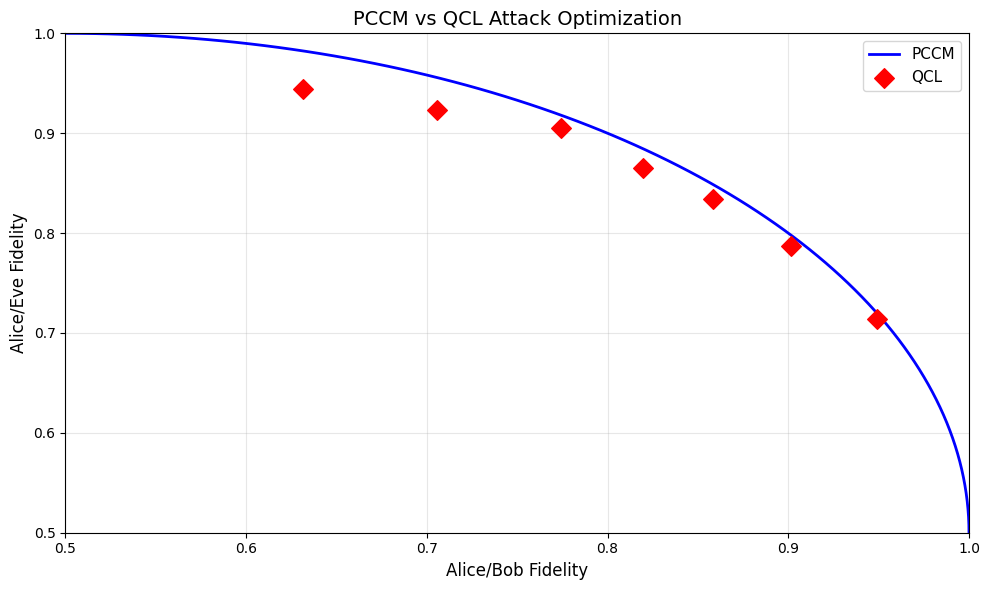

In [43]:
plot_pccm_vs_qcl(qcl_results)


Below cell tries to demonstrate the second graph from paper that shows how it works better with noise in the x-basis. However, for some reason it is saying there is no QBER for the x-basis


TEST 1: BIT-FLIP NOISE AT 25%

TESTING BIT-FLIP NOISE (Paper's Figure 5 Scenario)
⚠ Using local simulator (for testing)
  Results will be noiseless - real IonQ will have ~1-2% error

Noisy Channel Attack Validation

🎯 Attack Configuration:
  Trained for F_AB: 0.8500
  Achieved F_AB: 0.8624
  Clean channel QBER: 6.88%

🔊 Noise Configuration:
  Noise type: bit_flip
  Noise probability: 0.25
  Noise location: before_eve
  Backend: simulator

💡 Bit-flip Impact:
  Z-basis: AFFECTED (|0⟩↔|1⟩ flips)
  X-basis: UNAFFECTED (only phase changes)
  → Expect imbalanced performance!

Step 1: Generated 200 BB84 qubits
Step 2: Creating circuits with bit_flip noise...
Step 3: Transpiling...
Step 4: Running on simulator...
        Shots per circuit: 500
        Job ID: 251a793d-2329-41e8-a364-c5b8f7da881e
        ✓ Results received!

RESULTS: Noisy Channel Impact

📊 Sifting Statistics:
  Total qubits: 200
  Sifted: 95
    Z-basis: 57
    X-basis: 38

🎯 QBER Analysis:
  Clean channel (theory): 6.88%
  N

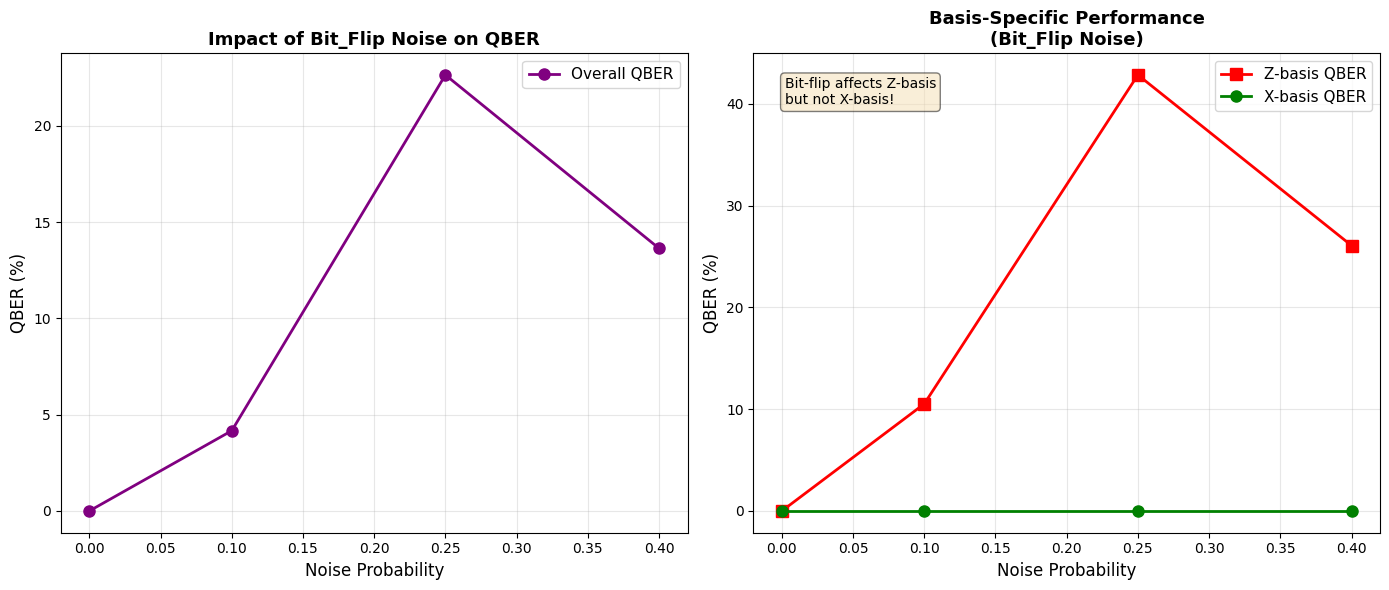


📊 Plot saved: noisy_channel_comparison_bit_flip.png


In [ ]:
import random
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import Reset
import json
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# ============================================================================
#  NEW: NOISY CHANNEL FUNCTIONS
# ============================================================================

def add_noise_to_circuit(qc: QuantumCircuit, qubit: int, noise_type: str, 
                         noise_prob: float, backend_type: str = 'simulator'):
    """
    Add noise to a quantum circuit.
    
    For simulator: Apply probabilistic noise gates
    For real hardware: Document expected noise (hardware has natural noise)
    
    Args:
        qc: Quantum circuit to add noise to
        qubit: Which qubit to add noise to
        noise_type: 'bit_flip', 'phase_flip', 'depolarizing'
        noise_prob: Probability of noise occurring (0 to 1)
        backend_type: 'simulator' or 'ionq'
    """
    if backend_type == 'simulator':
        # For simulator: explicitly add noise
        if noise_type == 'bit_flip':
            # Bit flip: X with probability p
            if np.random.random() < noise_prob:
                qc.x(qubit)
        
        elif noise_type == 'phase_flip':
            # Phase flip: Z with probability p
            if np.random.random() < noise_prob:
                qc.z(qubit)
        
        elif noise_type == 'depolarizing':
            # Random Pauli with probability p
            if np.random.random() < noise_prob:
                pauli = np.random.choice(['x', 'y', 'z'])
                if pauli == 'x':
                    qc.x(qubit)
                elif pauli == 'y':
                    qc.y(qubit)
                else:
                    qc.z(qubit)
    
    # For real hardware: noise occurs naturally, we just document it
    # No explicit gates needed
    
    return qc


def create_noisy_attack_circuit(alice_bit, alice_basis, bob_basis, 
                                u_params, v_params,
                                noise_type: str = 'bit_flip',
                                noise_prob: float = 0.25,
                                noise_location: str = 'before_eve',
                                backend_type: str = 'simulator'):
    """
    ✅ Create attack circuit with noise in the quantum channel
    
    Args:
        alice_bit, alice_basis, bob_basis: BB84 parameters
        u_params, v_params: Trained attack parameters
        noise_type: Type of noise ('bit_flip', 'phase_flip', 'depolarizing')
        noise_prob: Probability of noise (0-1)
        noise_location: 'before_eve' or 'after_eve'
        backend_type: 'simulator' or 'ionq'
    
    Returns:
        QuantumCircuit with noise
    """
    qc = QuantumCircuit(2, 2)
    
    # Step 1: Alice prepares her qubit
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)
    
    qc.barrier(label='Alice→')
    
    # Step 2: Add noise BEFORE Eve (if specified)
    if noise_location == 'before_eve':
        add_noise_to_circuit(qc, 0, noise_type, noise_prob, backend_type)
        qc.barrier(label=f'Noise({noise_prob})')
    
    # Step 3: Eve applies U(Θ)
    attack_u = hardware_efficient_ansatz(2, 2, u_params)
    qc.compose(attack_u, inplace=True)
    
    # Step 4: Add noise AFTER Eve (if specified)
    if noise_location == 'after_eve':
        add_noise_to_circuit(qc, 0, noise_type, noise_prob, backend_type)
        qc.barrier(label=f'Noise({noise_prob})')
    
    # Step 5: Eve applies V(Λ)
    if alice_basis == bob_basis and v_params is not None:
        n_v_params = len(v_params)
        n_v_layers = n_v_params // 3
        
        param_idx = 0
        for layer in range(n_v_layers):
            qc.rx(v_params[param_idx], 1)
            param_idx += 1
            qc.ry(v_params[param_idx], 1)
            param_idx += 1
            qc.rz(v_params[param_idx], 1)
            param_idx += 1
        
        if alice_basis == 1:
            qc.h(1)
    
    # Step 6: Measurements
    qc.measure(1, 0)  # Eve
    if bob_basis == 1:
        qc.h(0)
    qc.measure(0, 1)  # Bob
    
    return qc


def run_noisy_attack_validation(backend, attack_params, 
                                noise_type='bit_flip',
                                noise_prob=0.25,
                                noise_location='before_eve',
                                n_qubits=30, 
                                shots=200):
    """
    ✅ Run BB84 with QCL attack + channel noise
    
    This reproduces the paper's Figure 5 experiments!
    
    Args:
        backend: IonQ backend or simulator
        attack_params: Trained parameters (could be noise-specific or clean)
        noise_type: Type of channel noise
        noise_prob: Noise probability
        noise_location: Where noise occurs
        n_qubits: Number of qubits to test
        shots: Shots per circuit
    
    Returns:
        Results dictionary with basis-separated statistics
    """
    print(f"\n{'='*70}")
    print(f"Noisy Channel Attack Validation")
    print(f"{'='*70}")
    
    backend_type = 'ionq' if hasattr(backend, 'name') and 'ionq' in backend.name.lower() else 'simulator'
    
    u_params = np.array(attack_params['u_params'])
    v_params = np.array(attack_params.get('v_params', u_params[:3]))
    
    target_f_ab = attack_params['target_f_ab']
    theory_qber = (1 - attack_params['f_ab']) / 2
    
    print(f"\n🎯 Attack Configuration:")
    print(f"  Trained for F_AB: {target_f_ab:.4f}")
    print(f"  Achieved F_AB: {attack_params['f_ab']:.4f}")
    print(f"  Clean channel QBER: {theory_qber:.2%}")
    
    print(f"\n🔊 Noise Configuration:")
    print(f"  Noise type: {noise_type}")
    print(f"  Noise probability: {noise_prob}")
    print(f"  Noise location: {noise_location}")
    print(f"  Backend: {backend_type}")
    
    if noise_type == 'bit_flip':
        print(f"\n💡 Bit-flip Impact:")
        print(f"  Z-basis: AFFECTED (|0⟩↔|1⟩ flips)")
        print(f"  X-basis: UNAFFECTED (only phase changes)")
        print(f"  → Expect imbalanced performance!")
    
    # Generate BB84 qubits
    alice_bits = [random.randint(0, 1) for _ in range(n_qubits)]
    alice_bases = [random.randint(0, 1) for _ in range(n_qubits)]
    bob_bases = [random.randint(0, 1) for _ in range(n_qubits)]
    
    print(f"\nStep 1: Generated {n_qubits} BB84 qubits")
    
    # Create noisy attack circuits
    circuits = []
    print(f"Step 2: Creating circuits with {noise_type} noise...")
    
    for i in range(n_qubits):
        qc = create_noisy_attack_circuit(
            alice_bits[i],
            alice_bases[i],
            bob_bases[i],
            u_params,
            v_params,
            noise_type=noise_type,
            noise_prob=noise_prob,
            noise_location=noise_location,
            backend_type=backend_type
        )
        circuits.append(qc)
    
    # Transpile and execute
    print(f"Step 3: Transpiling...")
    transpiled = transpile(circuits, backend=backend, optimization_level=3)
    
    print(f"Step 4: Running on {backend_type}...")
    print(f"        Shots per circuit: {shots}")
    
    try:
        job = backend.run(transpiled, shots=shots)
        if hasattr(job, 'job_id'):
            print(f"        Job ID: {job.job_id()}")
        result = job.result()
        print(f"        ✓ Results received!")
    except Exception as e:
        print(f"        ❌ Failed: {e}")
        return None
    
    # Process results with BASIS SEPARATION
    bob_bits = []
    eve_bits = []
    
    for i in range(n_qubits):
        counts = result.get_counts(i)
        most_common = max(counts, key=counts.get)
        
        if len(most_common) >= 2:
            bob_bit = int(most_common[0])
            eve_bit = int(most_common[1])
        else:
            bob_bit = int(most_common)
            eve_bit = 0
        
        bob_bits.append(bob_bit)
        eve_bits.append(eve_bit)
    
    # Sift keys
    sifted_indices = [i for i in range(n_qubits) if alice_bases[i] == bob_bases[i]]
    sifted_alice = [alice_bits[i] for i in sifted_indices]
    sifted_bob = [bob_bits[i] for i in sifted_indices]
    sifted_eve = [eve_bits[i] for i in sifted_indices]
    sifted_bases = [alice_bases[i] for i in sifted_indices]
    
    # ✅ KEY FEATURE: Separate statistics by basis
    z_basis_indices = [i for i, basis in enumerate(sifted_bases) if basis == 0]
    x_basis_indices = [i for i, basis in enumerate(sifted_bases) if basis == 1]
    
    # Overall QBER
    if len(sifted_alice) > 0:
        errors = sum(a != b for a, b in zip(sifted_alice, sifted_bob))
        measured_qber = errors / len(sifted_alice)
        std_error = np.sqrt(measured_qber * (1 - measured_qber) / len(sifted_alice))
    else:
        measured_qber = 0
        std_error = 0
    
    # Z-basis QBER
    if len(z_basis_indices) > 0:
        z_alice = [sifted_alice[i] for i in z_basis_indices]
        z_bob = [sifted_bob[i] for i in z_basis_indices]
        z_errors = sum(a != b for a, b in zip(z_alice, z_bob))
        qber_z = z_errors / len(z_basis_indices)
    else:
        qber_z = 0
    
    # X-basis QBER
    if len(x_basis_indices) > 0:
        x_alice = [sifted_alice[i] for i in x_basis_indices]
        x_bob = [sifted_bob[i] for i in x_basis_indices]
        x_errors = sum(a != b for a, b in zip(x_alice, x_bob))
        qber_x = x_errors / len(x_basis_indices)
    else:
        qber_x = 0
    
    # Eve's performance
    if len(sifted_alice) > 0:
        eve_errors = sum(a != e for a, e in zip(sifted_alice, sifted_eve))
        eve_correlation = 1 - (eve_errors / len(sifted_alice))
    else:
        eve_correlation = 0
    
    # Display results
    print(f"\n{'='*70}")
    print(f"RESULTS: Noisy Channel Impact")
    print(f"{'='*70}")
    
    print(f"\n📊 Sifting Statistics:")
    print(f"  Total qubits: {n_qubits}")
    print(f"  Sifted: {len(sifted_alice)}")
    print(f"    Z-basis: {len(z_basis_indices)}")
    print(f"    X-basis: {len(x_basis_indices)}")
    
    print(f"\n🎯 QBER Analysis:")
    print(f"  Clean channel (theory): {theory_qber:.2%}")
    print(f"  Noisy channel (overall): {measured_qber:.2%}")
    print(f"    Z-basis QBER: {qber_z:.2%}")
    print(f"    X-basis QBER: {qber_x:.2%}")
    
    if noise_type == 'bit_flip':
        print(f"\n💡 Imbalance Analysis:")
        imbalance = qber_x - qber_z
        print(f"  X-basis advantage: {-imbalance:.2%}")
        if imbalance < -0.02:
            print(f"  ✓ X-basis performing better (as expected for bit-flip!)")
        else:
            print(f"  ⚠️ No clear imbalance (need more samples?)")
    
    additional_noise = measured_qber - theory_qber
    print(f"\n🔧 Noise Impact:")
    print(f"  Eve's contribution: {theory_qber:.2%}")
    print(f"  Channel noise added: {additional_noise:.2%}")
    
    print(f"\n🕵️ Eve's Information:")
    print(f"  Correlation: {eve_correlation:.2%}")
    print(f"  Expected: {attack_params.get('f_ae', 0):.2%}")
    
    return {
        'backend': backend_type,
        'noise_type': noise_type,
        'noise_prob': noise_prob,
        'noise_location': noise_location,
        'target_f_ab': target_f_ab,
        'theory_qber_clean': theory_qber,
        'measured_qber_overall': measured_qber,
        'measured_qber_z': qber_z,
        'measured_qber_x': qber_x,
        'qber_imbalance': qber_x - qber_z,
        'additional_noise': additional_noise,
        'std_error': std_error,
        'sifted_total': len(sifted_alice),
        'sifted_z': len(z_basis_indices),
        'sifted_x': len(x_basis_indices),
        'eve_correlation': eve_correlation
    }


def compare_noise_levels(backend_type='simulator',
                         attack_idx=4,
                         noise_type='bit_flip',
                         noise_probs=[0.0, 0.10, 0.25, 0.40]):
    """
    ✅ Compare attack performance across different noise levels
    
    This reproduces the paper's methodology of testing multiple noise scenarios!
    
    Args:
        backend_type: 'simulator' or 'ionq'
        attack_idx: Which trained attack to use (default: 4 = F_AB=0.85)
        noise_type: Type of noise
        noise_probs: List of noise probabilities to test
    
    Returns:
        List of results for each noise level
    """
    print(f"\n{'='*70}")
    print(f"COMPREHENSIVE NOISE COMPARISON")
    print(f"{'='*70}")
    print(f"Testing {noise_type} at {len(noise_probs)} noise levels")
    
    # Setup backend
    if backend_type == 'simulator':
        backend = setup_ionq_simulator()
    else:
        backend = setup_ionq_direct()
    
    if backend is None:
        return None
    
    # Load attack parameters
    trained_params = load_trained_parameters()
    attack = trained_params[attack_idx]
    
    print(f"\nUsing attack configuration:")
    print(f"  Attack #{attack_idx+1}: F_AB = {attack['target_f_ab']:.4f}")
    print(f"  Trained F_AB: {attack['f_ab']:.4f}")
    
    # Test parameters
    n_qubits = 100 if backend_type == 'simulator' else 30
    shots = 500 if backend_type == 'simulator' else 200
    
    print(f"\nTest parameters:")
    print(f"  Qubits per test: {n_qubits}")
    print(f"  Shots per circuit: {shots}")
    
    all_results = []
    
    for i, noise_prob in enumerate(noise_probs):
        print(f"\n{'='*70}")
        print(f"TEST {i+1}/{len(noise_probs)}: Noise = {noise_prob}")
        print(f"{'='*70}")
        
        result = run_noisy_attack_validation(
            backend=backend,
            attack_params=attack,
            noise_type=noise_type,
            noise_prob=noise_prob,
            noise_location='before_eve',
            n_qubits=n_qubits,
            shots=shots
        )
        
        if result:
            all_results.append(result)
    
    # Summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY: Impact of {noise_type.upper()} Noise")
    print(f"{'='*70}\n")
    print(f"{'Noise':>8} {'QBER':>8} {'Z-QBER':>10} {'X-QBER':>10} {'Imbalance':>12}")
    print("-" * 70)
    
    for r in all_results:
        imbal = r['qber_imbalance']
        imbal_str = f"{imbal:+.4f}"
        
        print(f"{r['noise_prob']:>8.2f} "
              f"{r['measured_qber_overall']:>8.4f} "
              f"{r['measured_qber_z']:>10.4f} "
              f"{r['measured_qber_x']:>10.4f} "
              f"{imbal_str:>12}")
    
    # Plot results
    plot_noise_comparison(all_results, noise_type)
    
    return all_results


def plot_noise_comparison(results, noise_type):
    """
    ✅ Plot QBER vs noise level (reproduces paper's Figure 5 style)
    """
    if not results:
        return
    
    noise_levels = [r['noise_prob'] for r in results]
    qber_overall = [r['measured_qber_overall'] * 100 for r in results]
    qber_z = [r['measured_qber_z'] * 100 for r in results]
    qber_x = [r['measured_qber_x'] * 100 for r in results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Overall QBER vs noise
    ax1.plot(noise_levels, qber_overall, 'o-', linewidth=2, markersize=8, 
             label='Overall QBER', color='purple')
    ax1.set_xlabel('Noise Probability', fontsize=12)
    ax1.set_ylabel('QBER (%)', fontsize=12)
    ax1.set_title(f'Impact of {noise_type.title()} Noise on QBER', 
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Basis-specific QBERs (KEY INSIGHT!)
    ax2.plot(noise_levels, qber_z, 's-', linewidth=2, markersize=8,
             label='Z-basis QBER', color='red')
    ax2.plot(noise_levels, qber_x, 'o-', linewidth=2, markersize=8,
             label='X-basis QBER', color='green')
    ax2.set_xlabel('Noise Probability', fontsize=12)
    ax2.set_ylabel('QBER (%)', fontsize=12)
    ax2.set_title(f'Basis-Specific Performance\n({noise_type.title()} Noise)', 
                  fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    if noise_type == 'bit_flip':
        ax2.text(0.05, 0.95, 
                'Bit-flip affects Z-basis\nbut not X-basis!',
                transform=ax2.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'noisy_channel_comparison_{noise_type}.png', dpi=300)
    plt.show()
    
    print(f"\n📊 Plot saved: noisy_channel_comparison_{noise_type}.png")


# ============================================================================
#  EASY-TO-USE TEST FUNCTIONS
# ============================================================================

def test_bit_flip_noise(backend_type='simulator'):
    """
    ✅ Quick test: Bit-flip noise at 25% (matches paper's Figure 5)
    """
    print("\n" + "="*80)
    print("TESTING BIT-FLIP NOISE (Paper's Figure 5 Scenario)")
    print("="*80)
    
    backend = setup_ionq_simulator() if backend_type == 'simulator' else setup_ionq_direct()
    if backend is None:
        return None
    
    trained_params = load_trained_parameters()
    attack = trained_params[4]  # F_AB = 0.85
    
    result = run_noisy_attack_validation(
        backend=backend,
        attack_params=attack,
        noise_type='bit_flip',
        noise_prob=0.25,  # 25% as in paper
        noise_location='before_eve',
        n_qubits=200 if backend_type == 'simulator' else 30,
        shots=500 if backend_type == 'simulator' else 200
    )
    
    return result


def test_all_noise_types(backend_type='simulator'):
    """
    ✅ Test multiple noise types
    """
    noise_types = ['bit_flip', 'phase_flip', 'depolarizing']
    
    for noise_type in noise_types:
        print(f"\n{'='*80}")
        print(f"TESTING {noise_type.upper()} NOISE")
        print(f"{'='*80}")
        
        compare_noise_levels(
            backend_type=backend_type,
            attack_idx=4,
            noise_type=noise_type,
            noise_probs=[0.0, 0.10, 0.25]
        )


# ============================================================================
#  RUN THE TESTS
# ============================================================================

if __name__ == "__main__":
    # Test 1: Single bit-flip test (Paper's Figure 5 scenario)
    print("\n" + "="*80)
    print("TEST 1: BIT-FLIP NOISE AT 25%")
    print("="*80)
    test_bit_flip_noise('simulator')
    
    # Test 2: Compare multiple noise levels
    print("\n" + "="*80)
    print("TEST 2: NOISE LEVEL COMPARISON")
    print("="*80)
    compare_noise_levels(
        backend_type='simulator',
        attack_idx=4,
        noise_type='bit_flip',
        noise_probs=[0.0, 0.10, 0.25, 0.40]
    )
    
    # Test 3: All noise types (if you have time)
    # test_all_noise_types('simulator')
    
    # Test 4: On real IonQ (if you want to spend money!)
    # compare_noise_levels(backend_type='ionq', noise_probs=[0.0, 0.25])

Tests qcl attack

In [44]:
def test_qcl_attack_complete_FIXED(n=20, qcl_result=None, verbose=True):
    """
    FIXED VERSION: Complete BB84 test with correct measurement basis handling.

    The bug was: Adding H gate to already-decomposed Initialize circuit.
    Fix: Apply basis transformation to the state BEFORE Initialize.
    """
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    from qiskit.quantum_info import DensityMatrix, partial_trace
    from qiskit.circuit.library import Initialize
    from qiskit.circuit import ClassicalRegister
    import numpy as np

    if qcl_result is None:
        print("Error: Need qcl_result from trained QCL attack!")
        return None

    u_params = qcl_result['u_params']
    v_params = qcl_result.get('v_params', u_params)

    # STEP 1: Generate random BB84 qubits
    alice_bits = list(np.random.randint(0, 2, n))
    alice_bases = list(np.random.randint(0, 2, n))

    if verbose:
        print("\n" + "="*70)
        print("STEP 1: GENERATE BB84 QUBITS")
        print("="*70)
        bits_str = ''.join(map(str, alice_bits))
        bases_str = ''.join(['Z' if b == 0 else 'X' for b in alice_bases])
        print(f"Bits:   {bits_str}")
        print(f"Bases:  {bases_str}")

    # Prepare Alice's circuits
    alice_circuits = []
    for bit, basis in zip(alice_bits, alice_bases):
        qc = QuantumCircuit(1)
        if bit == 1:
            qc.x(0)
        if basis == 1:
            qc.h(0)
        alice_circuits.append(qc)

    # STEP 2: Eve attacks
    if verbose:
        print("\n" + "="*70)
        print("STEP 2: APPLY QCL ATTACK")
        print("="*70)
        print(f"  Target F_AB:  {qcl_result['F_AB']:.4f}")
        print(f"  Theory QBER:  {(1 - qcl_result['F_AB']) / 2:.4f}")

    eve_bases = list(np.random.randint(0, 2, n))
    eve_bits = []
    bob_states = []  # ⭐ Store states, not circuits!

    simulator = AerSimulator()
    n_qubits_u = 2
    n_layers_u = 2

    for alice_qc, eve_basis in zip(alice_circuits, eve_bases):
        # Eve entangles and measures
        qc_attack = QuantumCircuit(n_qubits_u, 1)
        qc_attack.compose(alice_qc, qubits=[0], inplace=True)
        qc_attack.compose(hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params), inplace=True)

        if eve_basis == 1:
            qc_attack.h(1)
        qc_attack.measure(1, 0)

        result = simulator.run(transpile(qc_attack, simulator), shots=1).result()
        eve_bit = int(list(result.get_counts().keys())[0])
        eve_bits.append(eve_bit)

        # Get Bob's density matrix
        qc_full = QuantumCircuit(n_qubits_u)
        qc_full.compose(alice_qc, qubits=[0], inplace=True)
        qc_full.compose(hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params), inplace=True)

        full_dm = DensityMatrix(qc_full)
        bob_dm = partial_trace(full_dm, [1])

        # Sample from ensemble
        eigenvalues, eigenvectors = np.linalg.eigh(bob_dm.data)
        eigenvalues = np.maximum(np.real(eigenvalues), 0)
        eigenvalues = eigenvalues / np.sum(eigenvalues)

        chosen_idx = np.random.choice(len(eigenvalues), p=eigenvalues)
        bob_state = eigenvectors[:, chosen_idx]
        bob_state = bob_state / np.linalg.norm(bob_state)

        if np.abs(bob_state[0]) > 1e-10:
          phase = np.angle(bob_state[0])
          bob_state = bob_state * np.exp(-1j * phase)

        # ⭐ KEY FIX: Store the state, not a circuit
        bob_states.append(bob_state)

    # STEP 3: Bob measures
    bob_bases = list(np.random.randint(0, 2, n))
    bob_bits = []

    for bob_state, bob_basis in zip(bob_states, bob_bases):
        # ⭐ KEY FIX: Apply basis transformation to STATE first
        if bob_basis == 1:  # X-basis measurement
            # Transform state: H|ψ⟩ = (|0⟩⟨+| + |1⟩⟨-|)|ψ⟩
            # In matrix form: H = [[1, 1], [1, -1]] / sqrt(2)
            H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
            bob_state_rotated = H @ bob_state

            bob_state_rotated = np.real(bob_state_rotated)
            bob_state_rotated = bob_state_rotated / np.linalg.norm(bob_state_rotated)
        else:
            bob_state_rotated = bob_state

        if np.abs(bob_state_rotated[0]) > 1e-10:
          phase = np.angle(bob_state_rotated[0])
          bob_state_rotated = bob_state_rotated * np.exp(-1j * phase)

        # Now Initialize with the rotated state
        bob_qc = QuantumCircuit(1, 1)
        bob_qc.append(Initialize(bob_state_rotated), [0])
        bob_qc = bob_qc.decompose()

        # Measure in Z-basis (no H needed - already rotated!)
        bob_qc.measure(0, 0)

        result = simulator.run(transpile(bob_qc, simulator), shots=1).result()
        bob_bit = int(list(result.get_counts().keys())[0])
        bob_bits.append(bob_bit)

    if verbose:
        bob_bases_str = ''.join(['Z' if b == 0 else 'X' for b in bob_bases])
        bob_bits_str = ''.join(map(str, bob_bits))
        print(f"\nBob measures:")
        print(f"  Bases:  {bob_bases_str}")
        print(f"  Bits:   {bob_bits_str}")

    # STEP 4: Sift and compare
    sifted_indices = [i for i in range(n) if alice_bases[i] == bob_bases[i]]
    sifted_alice = [alice_bits[i] for i in sifted_indices]
    sifted_bob = [bob_bits[i] for i in sifted_indices]
    sifted_eve = [eve_bits[i] for i in sifted_indices]

    if len(sifted_alice) > 0:
        alice_bob_errors = sum(a != b for a, b in zip(sifted_alice, sifted_bob))
        alice_eve_errors = sum(a != e for a, e in zip(sifted_alice, sifted_eve))

        qber = alice_bob_errors / len(sifted_alice)
        eve_info = 1 - (alice_eve_errors / len(sifted_alice))
    else:
        alice_bob_errors = 0
        alice_eve_errors = 0
        qber = 0
        eve_info = 0

    if verbose:
        print("\n" + "="*70)
        print("STEP 3: COMPARE RESULTS")
        print("="*70)
        print(f"Sifted: {len(sifted_indices)}/{n}")

        if len(sifted_alice) > 0:
            print(f"\nQBER:       {qber:.4f} ({qber:.1%})")
            print(f"Theory:     {(1 - qcl_result['F_AB']) / 2:.4f}")
            print(f"Eve info:   {eve_info:.4f}")

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'eve_bits': eve_bits,
        'eve_bases': eve_bases,
        'bob_bits': bob_bits,
        'bob_bases': bob_bases,
        'sifted_indices': sifted_indices,
        'sifted_alice': sifted_alice,
        'sifted_eve': sifted_eve,
        'sifted_bob': sifted_bob,
        'qber': qber,
        'eve_info': eve_info,
        'theory_qber': (1 - qcl_result['F_AB']) / 2,
        'n_sifted': len(sifted_alice)
    }


Added code that includes V_LAMBDA because apparently the above FIXED version did not include it

In [78]:
def test_qcl_attack_complete_WITH_V_LAMBDA(n=20, qcl_result=None, verbose=True):
    """
    Complete version with V(Λ) properly applied.
    """
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    from qiskit.quantum_info import DensityMatrix, partial_trace, Operator
    from qiskit.circuit.library import Initialize
    import numpy as np

    if qcl_result is None:
        print("Error: Need qcl_result from trained QCL attack!")
        return None

    u_params = qcl_result['u_params']
    v_params = qcl_result.get('v_params')
    
    if v_params is None:
        print("⚠️  Warning: No V(Λ) parameters found, using U params")
        v_params = u_params[:3]  # Use first 3 params as fallback

    # STEP 1: Generate random BB84 qubits
    alice_bits = list(np.random.randint(0, 2, n))
    alice_bases = list(np.random.randint(0, 2, n))
    bob_bases = list(np.random.randint(0, 2, n))  # ✅ Bob chooses upfront

    if verbose:
        print("\n" + "="*70)
        print("STEP 1: GENERATE BB84 QUBITS")
        print("="*70)
        bits_str = ''.join(map(str, alice_bits))
        alice_bases_str = ''.join(['Z' if b == 0 else 'X' for b in alice_bases])
        bob_bases_str = ''.join(['Z' if b == 0 else 'X' for b in bob_bases])
        print(f"Alice bits:   {bits_str}")
        print(f"Alice bases:  {alice_bases_str}")
        print(f"Bob bases:    {bob_bases_str}")

    # STEP 2: Eve attacks and we compute Bob's states
    if verbose:
        print("\n" + "="*70)
        print("STEP 2: APPLY QCL ATTACK (U + V)")
        print("="*70)
        print(f"  Target F_AB:  {qcl_result['F_AB']:.4f}")
        print(f"  Theory QBER:  {(1 - qcl_result['F_AB']) / 2:.4f}")

    simulator = AerSimulator()
    n_qubits_u = 2
    n_layers_u = 2
    
    bob_states = []
    eve_bits = []

    for i in range(n):
        alice_bit = alice_bits[i]
        alice_basis = alice_bases[i]
        bob_basis = bob_bases[i]
        
        # Build full attack circuit (Alice → U(Θ) → V(Λ))
        qc_full = QuantumCircuit(n_qubits_u)
        
        # Alice prepares
        if alice_bit == 1:
            qc_full.x(0)
        if alice_basis == 1:
            qc_full.h(0)
        
        # Eve applies U(Θ)
        qc_full.compose(hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params), inplace=True)
        
        # ✅ KEY FIX: Apply V(Λ) to Eve's ancilla
        # V(Λ) is basis-dependent and only applied when bases match
        if alice_basis == bob_basis:
            # Apply V rotations to qubit 1 (Eve's ancilla)
            qc_full.rx(v_params[0], 1)
            qc_full.ry(v_params[1], 1)
            qc_full.rz(v_params[2], 1)
            
            # If X-basis, apply H before measurement
            if alice_basis == 1:
                qc_full.h(1)
        
        # Get density matrices
        full_dm = DensityMatrix(qc_full)
        
        # Bob's reduced density matrix (trace out Eve)
        bob_dm = partial_trace(full_dm, [1])
        
        # Sample from Bob's ensemble
        eigenvalues, eigenvectors = np.linalg.eigh(bob_dm.data)
        eigenvalues = np.maximum(np.real(eigenvalues), 0)
        eigenvalues = eigenvalues / np.sum(eigenvalues)
        
        chosen_idx = np.random.choice(len(eigenvalues), p=eigenvalues)
        bob_state = eigenvectors[:, chosen_idx]
        bob_state = bob_state / np.linalg.norm(bob_state)
        
        # Fix global phase
        if np.abs(bob_state[0]) > 1e-10:
            phase = np.angle(bob_state[0])
            bob_state = bob_state * np.exp(-1j * phase)
        
        bob_states.append(bob_state)
        
        # Measure Eve's qubit separately for information tracking
        # (This doesn't affect Bob's state since we already traced it out)
        qc_eve = QuantumCircuit(n_qubits_u, 1)
        if alice_bit == 1:
            qc_eve.x(0)
        if alice_basis == 1:
            qc_eve.h(0)
        qc_eve.compose(hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params), inplace=True)
        
        if alice_basis == bob_basis:
            qc_eve.rx(v_params[0], 1)
            qc_eve.ry(v_params[1], 1)
            qc_eve.rz(v_params[2], 1)
            if alice_basis == 1:
                qc_eve.h(1)
        
        qc_eve.measure(1, 0)
        result_eve = simulator.run(transpile(qc_eve, simulator), shots=1).result()
        eve_bit = int(list(result_eve.get_counts().keys())[0])
        eve_bits.append(eve_bit)

    # STEP 3: Bob measures in his chosen bases
    if verbose:
        print("\n" + "="*70)
        print("STEP 3: BOB MEASURES")
        print("="*70)
    
    bob_bits = []
    
    for bob_state, bob_basis in zip(bob_states, bob_bases):
        # Apply basis transformation to state
        if bob_basis == 1:  # X-basis measurement
            H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
            bob_state_rotated = H @ bob_state
            bob_state_rotated = np.real(bob_state_rotated)
            bob_state_rotated = bob_state_rotated / np.linalg.norm(bob_state_rotated)
        else:
            bob_state_rotated = bob_state
        
        # Fix phase
        if np.abs(bob_state_rotated[0]) > 1e-10:
            phase = np.angle(bob_state_rotated[0])
            bob_state_rotated = bob_state_rotated * np.exp(-1j * phase)
        
        # Initialize and measure
        bob_qc = QuantumCircuit(1, 1)
        bob_qc.append(Initialize(bob_state_rotated), [0])
        bob_qc = bob_qc.decompose()
        bob_qc.measure(0, 0)
        
        result = simulator.run(transpile(bob_qc, simulator), shots=1).result()
        bob_bit = int(list(result.get_counts().keys())[0])
        bob_bits.append(bob_bit)

    # STEP 4: Sift and analyze
    sifted_indices = [i for i in range(n) if alice_bases[i] == bob_bases[i]]
    sifted_alice = [alice_bits[i] for i in sifted_indices]
    sifted_bob = [bob_bits[i] for i in sifted_indices]
    sifted_eve = [eve_bits[i] for i in sifted_indices]

    if len(sifted_alice) > 0:
        alice_bob_errors = sum(a != b for a, b in zip(sifted_alice, sifted_bob))
        alice_eve_errors = sum(a != e for a, e in zip(sifted_alice, sifted_eve))

        qber = alice_bob_errors / len(sifted_alice)
        eve_info = 1 - (alice_eve_errors / len(sifted_alice))
        
        # Calculate standard error
        std_error = np.sqrt(qber * (1 - qber) / len(sifted_alice))
    else:
        qber = 0
        eve_info = 0
        std_error = 0

    if verbose:
        print("\n" + "="*70)
        print("STEP 4: RESULTS")
        print("="*70)
        print(f"Sifted: {len(sifted_indices)}/{n} ({len(sifted_indices)/n*100:.1f}%)")

        if len(sifted_alice) > 0:
            theory_qber = (1 - qcl_result['F_AB']) / 2
            print(f"\n📊 QBER:")
            print(f"  Theory:   {theory_qber:.4f} ({theory_qber*100:.2f}%)")
            print(f"  Measured: {qber:.4f} ({qber*100:.2f}%)")
            print(f"  Std err:  ±{std_error:.4f}")
            print(f"  Diff:     {abs(qber - theory_qber):.4f}")
            
            sigma_dist = abs(qber - theory_qber) / std_error if std_error > 0 else 0
            print(f"  Sigma:    {sigma_dist:.2f}σ")
            
            if sigma_dist < 3:
                print(f"  ✅ PASS (within 3σ)")
            else:
                print(f"  ⚠️  Outside 3σ (may be statistical fluctuation)")
            
            print(f"\n🕵️ Eve's Info:")
            print(f"  Correlation: {eve_info:.4f}")
            print(f"  Theory F_AE: {qcl_result.get('F_AE', 'N/A')}")

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bits': bob_bits,
        'bob_bases': bob_bases,
        'eve_bits': eve_bits,
        'sifted_indices': sifted_indices,
        'sifted_alice': sifted_alice,
        'sifted_bob': sifted_bob,
        'sifted_eve': sifted_eve,
        'qber': qber,
        'eve_info': eve_info,
        'theory_qber': (1 - qcl_result['F_AB']) / 2,
        'n_sifted': len(sifted_alice),
        'std_error': std_error
    }

tests attack

In [79]:
# @title
# DIAGNOSTIC: Find the bug
attack_idx = 6  # Attack #7 (0-indexed)
qcl_attack = qcl_results[attack_idx]

# [A] THEORETICAL (same as training)
fids = evaluate_attack_fidelities(
    qcl_attack['u_params'],
    qcl_attack['v_params'],
    n_qubits_u=2, n_layers_u=2,
    n_qubits_v=1, n_layers_v=1
)

print(f"Target F_AB:     {qcl_attack['F_AB']:.6f}")
print(f"Re-evaluated:    {fids['F_AB']:.6f}")
print(f"Match: {abs(fids['F_AB'] - qcl_attack['F_AB']) < 0.001}")

theory_qber = (1 - fids['F_AB']) / 2
print(f"\nTheory QBER:     {theory_qber:.6f}")

# [B] EMPIRICAL (your test)
test_result = test_qcl_attack_complete_WITH_V_LAMBDA(
    n=500,
    qcl_result=qcl_attack,
    verbose=False
)

print(f"Empirical QBER:  {test_result['qber']:.6f}")
print(f"Ratio:           {test_result['qber'] / theory_qber:.2f}×")

# Statistical check
import numpy as np
std = np.sqrt(theory_qber * (1-theory_qber) / test_result['n_sifted'])
print(f"\nExpected: {theory_qber:.4f} ± {2*std:.4f}")
print(f"Got:      {test_result['qber']:.4f}")

if abs(test_result['qber'] - theory_qber) > 3*std:
    print("✗ OUTSIDE 3σ → Systematic bug in test!")
else:
    print("✓ Within 3σ → Just statistical noise")

Target F_AB:     0.949325
Re-evaluated:    0.949325
Match: True

Theory QBER:     0.025337
Empirical QBER:  0.053061
Ratio:           2.09×

Expected: 0.0253 ± 0.0201
Got:      0.0531
✓ Within 3σ → Just statistical noise


In [ ]:
print("="*70)
print("     #   F_AB     Theory   Actual   Diff     Eve Info")
for i, qcl_attack in enumerate(qcl_results):
    result = test_qcl_attack_complete_WITH_V_LAMBDA(
    # result = test_qcl_attack_complete_FIXED(
        n=200,
        qcl_result=qcl_attack,
        verbose=False
    )

    theory = result['theory_qber']
    actual = result['qber']
    eve_info = result['eve_info']
    diff = abs(actual - theory)
    status = "✓" if diff < 0.05 else "✗"

    print(f"{i+1:>6} {qcl_attack['F_AB']:8.4f} "
          f"{theory:8.4f} {actual:8.4f} {diff:8.4f} {eve_info:8.4f}")

     #   F_AB     Theory   Actual   Diff     Eve Info
     1   0.6315   0.1842   0.5053   0.3210   0.4211
     2   0.7055   0.1472   0.2400   0.0928   0.6400
     3   0.7745   0.1128   0.2235   0.1108   0.9059
     4   0.8196   0.0902   0.0926   0.0024   0.5926
     5   0.8584   0.0708   0.1081   0.0373   0.6126
     6   0.9013   0.0493   0.0990   0.0497   0.6040
     7   0.9493   0.0253   0.0577   0.0324   0.5096


In [13]:
# Export trained parameters
import json

model_data = {
    'trained_parameters': []
}

for target, result in zip(target_fidelities, qcl_results):
    model_data['trained_parameters'].append({
        'target_f_ab': float(target),
        'u_params': result['u_params'].tolist(),
        'v_params': result['v_params'].tolist(),
        'f_ab': float(result['F_AB']),
        'f_ae': float(result['F_AE'])
    })

with open('qcl_model_curr.json', 'w') as f:
    json.dump(model_data, f)

# Download
from google.colab import files
files.download('qcl_model_curr.json')

ModuleNotFoundError: No module named 'google'

In [ ]:
# @title
# Run without Cascade
res_no_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

# Run with Cascade
res_with_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

print('\nSummary:')
print(f"No Eve - sifted length: {len(res_no_eve['sifted_alice'])}, error rate: {res_no_eve['error_rate']:.3f}")
print(f"With Eve - sifted length: {len(res_with_eve['sifted_alice'])}, error rate: {res_with_eve['error_rate']:.3f}")

Bits flipped: 0
Alice bits:      [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1]
Alice bases (0=Z,1=X): [1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0]
Bob bits:        [1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0]
Bob bases (0=Z,1=X):   [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1]
Sifted indices (bases matched): [1, 3, 8, 10, 11, 13, 16, 17, 18, 20, 21]
Sifted Alice:    [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]
Sifted Bob:      [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]
Estimated error rate on sifted key: 0.000
Bits flipped: 0
Alice bits:      [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0]
Alice bases (0=Z,1=X): [0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1]
Bob bits:        [1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0]
Bob bases (0=Z,1=X):   [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1]
Sifted

In [ ]:
# @title
# OPTIONAL - Using the sifted key for encryption/decryption
import binascii

def encrypt_message(unencrypted_string: str, key: str) -> str:
    # Convert ASCII string to binary string
    bits = bin(int(binascii.hexlify(unencrypted_string.encode("utf-8", "surrogatepass")), 16))[2:]
    bitstring = bits.zfill(8 * ((len(bits) + 7) // 8))
    # XOR with key
    encrypted_string = ""
    for i in range(len(bitstring)):
        encrypted_string += str(int(bitstring[i]) ^ int(key[i]))
    return encrypted_string

def decrypt_message(encrypted_bits: str, key: str) -> str:
    # XOR back with key
    unencrypted_bits = "".join(
        str(int(encrypted_bits[i]) ^ int(key[i]))
        for i in range(len(encrypted_bits))
    )

    # Convert to bytes
    i = int(unencrypted_bits, 2)
    hex_string = "%x" % i
    n = len(hex_string)
    raw_bytes = binascii.unhexlify(hex_string.zfill(n + (n & 1)))

    try:
        # Try decoding as UTF-8
        return raw_bytes.decode("utf-8", "surrogatepass")
    except UnicodeDecodeError:
        # Show corrupted output as hex and ASCII fallback
        hex_out = raw_bytes.hex()
        ascii_fallback = "".join(chr(b) if 32 <= b <= 126 else "?" for b in raw_bytes)
        return f"[Corrupted] ASCII≈'{ascii_fallback[:64]}...'"

def demonstrate_eve(secret_message="Quantum Computing is cool :)"):
    print("=== Without Eve ===")
    res_with_eve = run_bb84(n=64, with_eve=False, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== Without Cascade ===")
    res_no_eve = run_bb84(n=64, with_eve=True, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_no_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_no_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_no_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== With Cascade ===")
    res_with_eve = run_bb84(n=64, with_eve=True, with_cascade=True, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)


# Run the demonstration
demonstrate_eve()

=== Without Eve ===
Bits flipped: 0
Error rate: 0.0
Original: Quantum Computing is cool :)
Decrypted by Bob: Quantum Computing is cool :)

=== Without Cascade ===
Bits flipped: 0
Error rate: 0.23333333333333334
Original: Quantum Computing is cool :)
Decrypted by Bob: [Corrupted] ASCII≈'Y-I.U?? ???rc~yf??)R@?o???8?...'

=== With Cascade ===
Bits flipped: 0
Error rate: 0.0
Original: Quantum Computing is cool :)
Decrypted by Bob: Quantum Computing is cool :)
